In [1]:
!pip install pandas matplotlib seaborn plotly

In [4]:
from google.colab import files
uploaded = files.upload()

Saving historical_data - historical_data.csv to historical_data - historical_data (1).csv


In [5]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index - fear_greed_index.csv to fear_greed_index - fear_greed_index.csv


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

In [9]:
trader_df = pd.read_csv("/content/historical_data - historical_data.csv")
sentiment_df = pd.read_csv("/content/fear_greed_index - fear_greed_index.csv")

In [10]:
print(trader_df.head())
print(sentiment_df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [43]:
print(sentiment_df.columns)
print(trader_df.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [45]:
print(trader_df.head())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [46]:
trader_df["date"] = pd.to_datetime(trader_df["Timestamp IST"], format="%d-%m-%Y %H:%M").dt.date

In [47]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.date

In [48]:
merged_df = trader_df.merge(sentiment_df, on="date", how="left")

In [49]:
print(merged_df[["date", "classification"]].head())

         date classification
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed


In [50]:
print(merged_df["classification"].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [51]:
avg_pnl = merged_df.groupby("classification")["Closed PnL"].mean()
print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


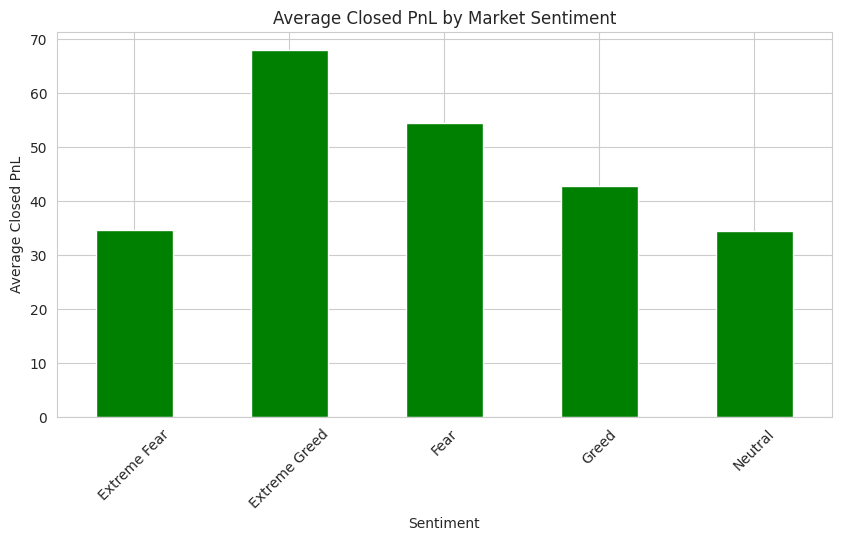

In [52]:
import matplotlib.pyplot as plt

avg_pnl.plot(kind="bar", figsize=(10,5), color="green")
plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.show()

In [53]:
merged_df["win"] = merged_df["Closed PnL"] > 0

In [54]:
win_rate = merged_df.groupby("classification")["win"].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


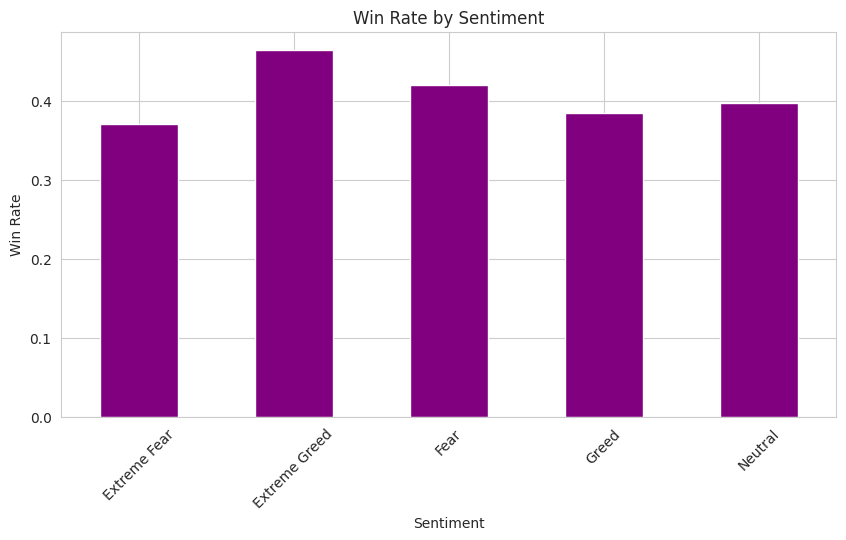

In [55]:
win_rate.plot(kind="bar", figsize=(10,5), color="purple")
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.show()

In [56]:
avg_size = merged_df.groupby("classification")["Size USD"].mean()
print(avg_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


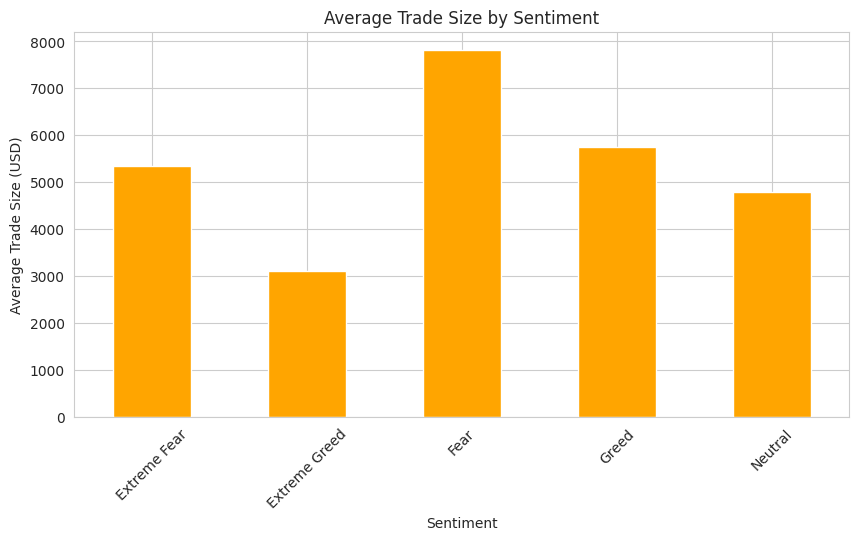

In [57]:
avg_size.plot(kind="bar", figsize=(10,5), color="orange")
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.show()

In [58]:
avg_fee = merged_df.groupby("classification")["Fee"].mean()
print(avg_fee)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


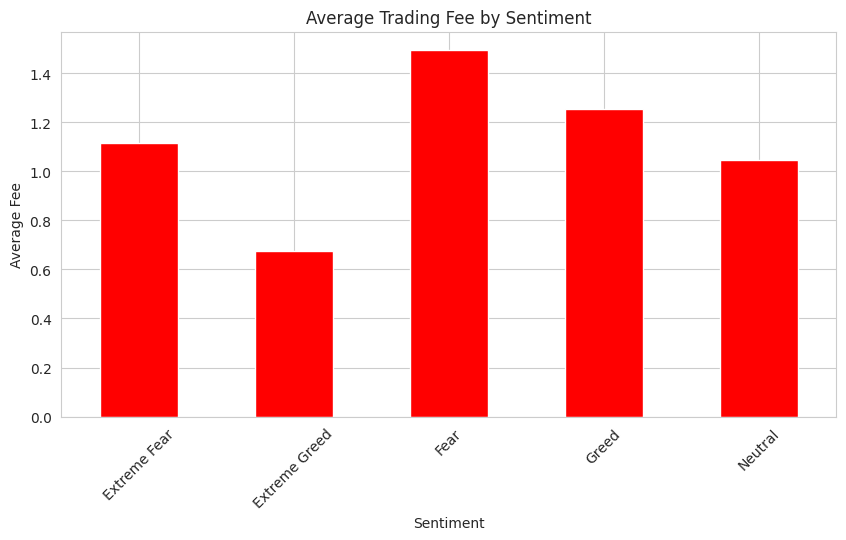

In [59]:
avg_fee.plot(kind="bar", figsize=(10,5), color="red")
plt.title("Average Trading Fee by Sentiment")
plt.ylabel("Average Fee")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.show()

In [60]:
total_pnl = merged_df.groupby("classification")["Closed PnL"].sum()
print(total_pnl)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


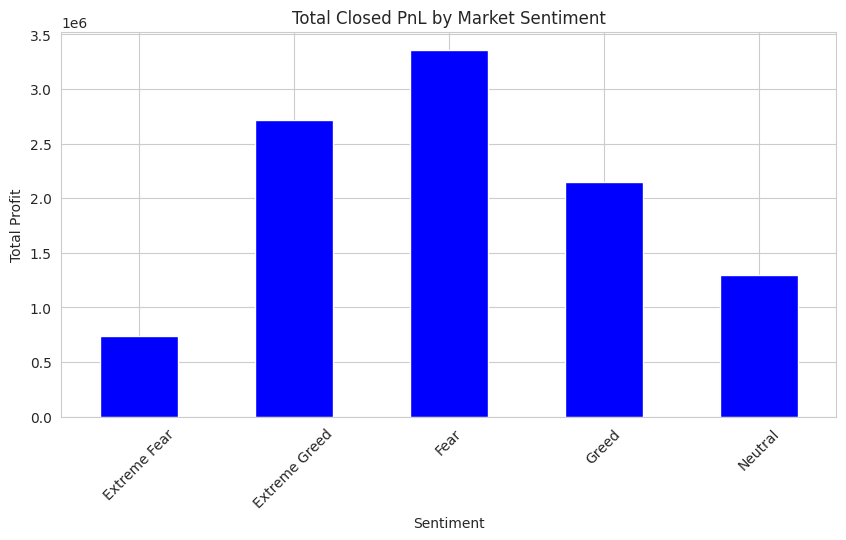

In [61]:
total_pnl.plot(kind="bar", figsize=(10,5), color="blue")
plt.title("Total Closed PnL by Market Sentiment")
plt.ylabel("Total Profit")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.show()

In [62]:
coin_perf = merged_df.groupby(["classification", "Coin"])["Closed PnL"].mean().reset_index()
print(coin_perf.head())

  classification  Coin  Closed PnL
0   Extreme Fear   @10   -0.031742
1   Extreme Fear  @107  -89.588788
2   Extreme Fear   @13   -0.061895
3   Extreme Fear  @142   15.529335
4   Extreme Fear   @16   -0.030214


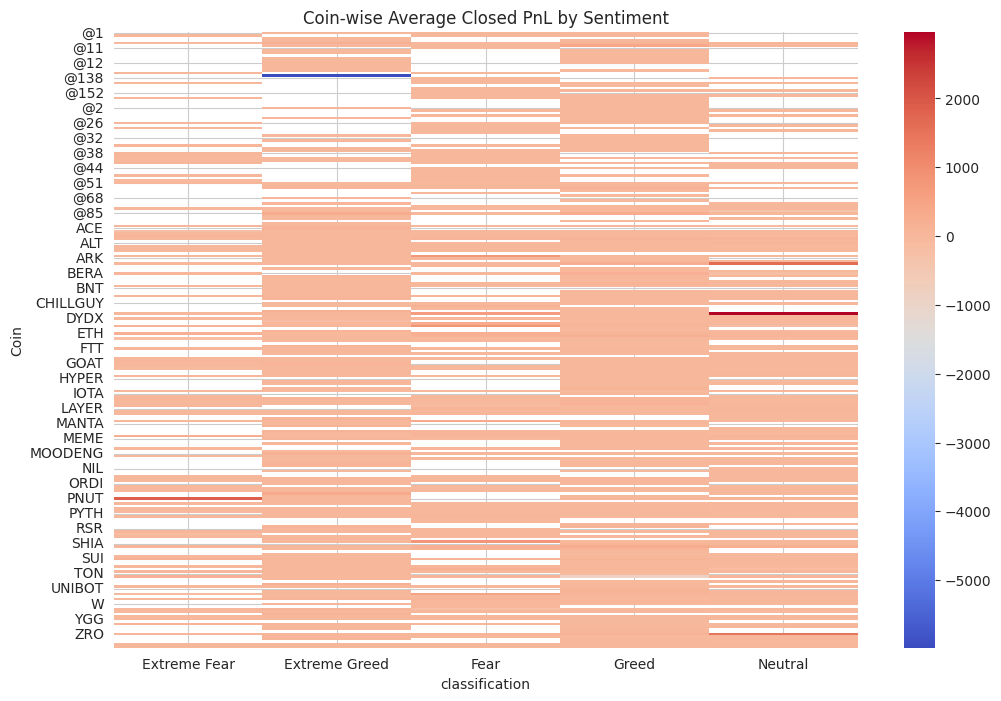

In [63]:
import seaborn as sns

pivot_table = coin_perf.pivot(index="Coin", columns="classification", values="Closed PnL")

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, cmap="coolwarm")
plt.title("Coin-wise Average Closed PnL by Sentiment")
plt.show()

In [64]:
summary = merged_df.groupby("classification").agg({
    "Closed PnL": "mean",
    "Size USD": "mean",
    "Fee": "mean",
    "win": "mean"
}).reset_index()

print(summary)

  classification  Closed PnL     Size USD       Fee       win
0   Extreme Fear   34.537862  5349.731843  1.116291  0.370607
1  Extreme Greed   67.892861  3112.251565  0.675902  0.464943
2           Fear   54.290400  7816.109931  1.495172  0.420768
3          Greed   42.743559  5736.884375  1.254372  0.384828
4        Neutral   34.307718  4782.732661  1.044798  0.396991


In [65]:
avg_pnl = merged_df.groupby("classification")["Closed PnL"].mean()
print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


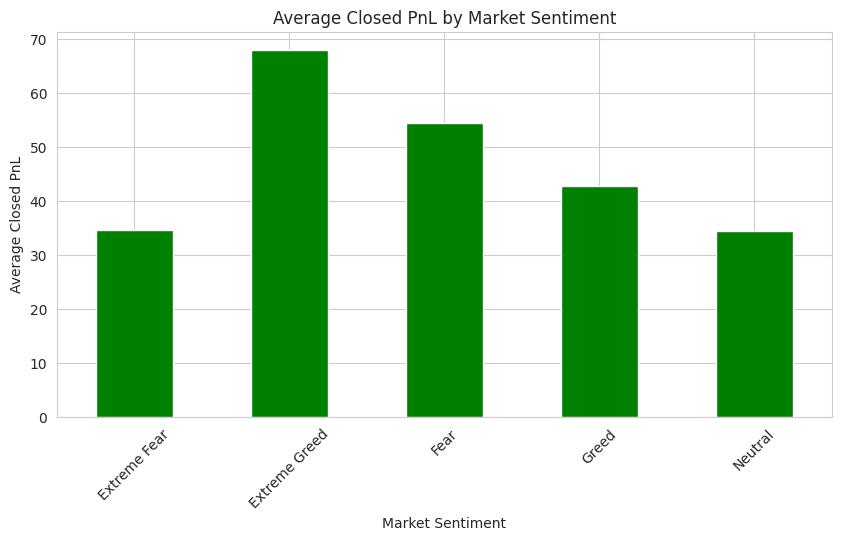

In [66]:
import matplotlib.pyplot as plt

avg_pnl = merged_df.groupby("classification")["Closed PnL"].mean()

avg_pnl.plot(kind="bar", figsize=(10,5), color="green")
plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

In [67]:
merged_df["win"] = merged_df["Closed PnL"] > 0
win_rate = merged_df.groupby("classification")["win"].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [68]:
merged_df["win"] = merged_df["Closed PnL"] > 0
win_rate = merged_df.groupby("classification")["win"].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


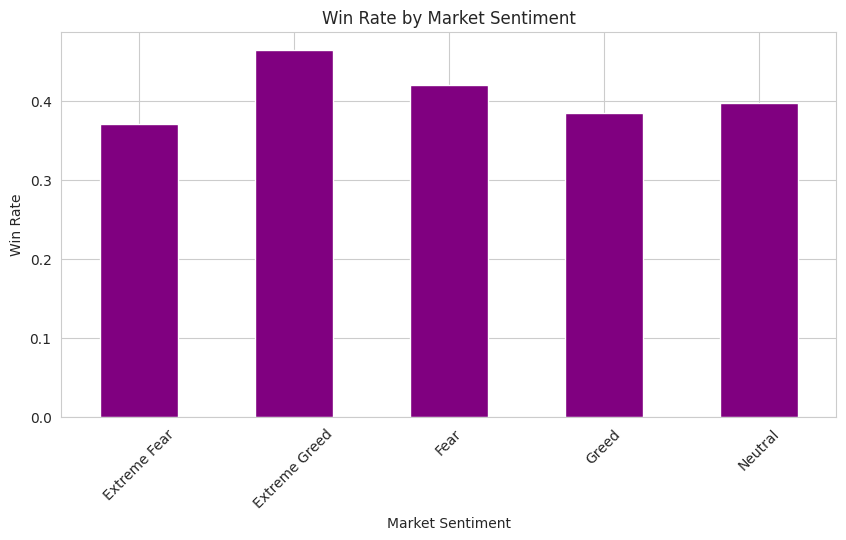

In [69]:
win_rate.plot(kind="bar", figsize=(10,5), color="purple")
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

In [70]:
avg_size = merged_df.groupby("classification")["Size USD"].mean()
print(avg_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


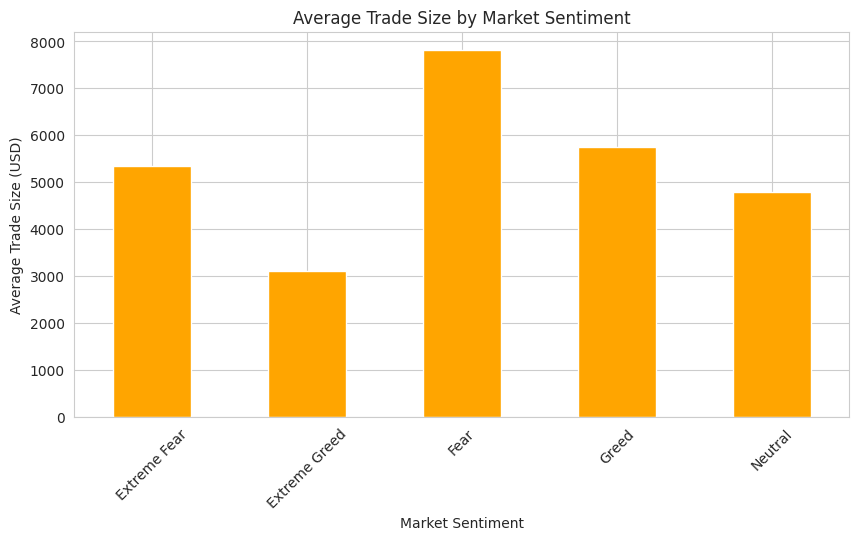

In [71]:
avg_size.plot(kind="bar", figsize=(10,5), color="orange")
plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

In [72]:
avg_size = merged_df.groupby("classification")["Size USD"].mean()
print(avg_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


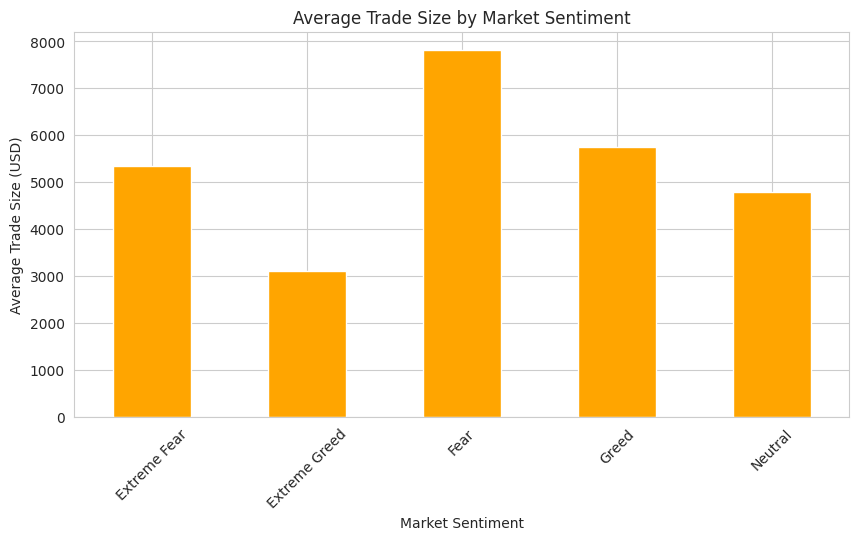

In [73]:
avg_size.plot(kind="bar", figsize=(10,5), color="orange")
plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

In [74]:
total_pnl = merged_df.groupby("classification")["Closed PnL"].sum()
print(total_pnl)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [75]:
total_pnl = merged_df.groupby("classification")["Closed PnL"].sum()
print(total_pnl)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


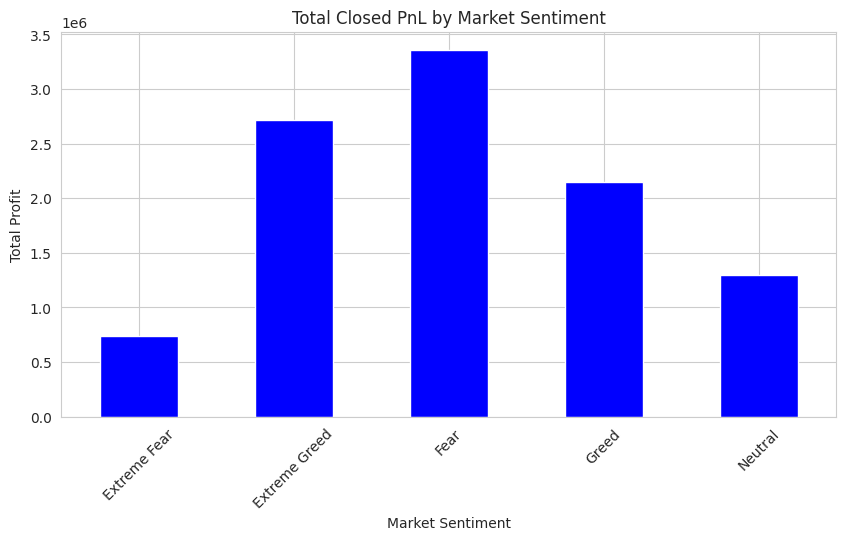

In [76]:
total_pnl.plot(kind="bar", figsize=(10,5), color="blue")
plt.title("Total Closed PnL by Market Sentiment")
plt.ylabel("Total Profit")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

In [79]:
merged_df.to_csv("merged_trader_sentiment.csv", index=False)

In [83]:
from google.colab import files
files.download("merged_trader_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>